In [1]:
%%capture
# 1. نصب virtualenv (اگر لازم باشه)
!pip install virtualenv

# 2. کلون کردن ریپو
!git clone https://github.com/SalesforceAIResearch/uni2ts.git

# 3. رفتن به پوشه پروژه
%cd uni2ts

# 4. نصب از سورس (editable install)
!pip install -e .

In [2]:
%%capture
!pip install --upgrade torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118

**بعد رستارت کن**

In [13]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from gluonts.dataset.pandas import PandasDataset
from gluonts.dataset.split import split

from uni2ts.model.moirai import MoiraiForecast, MoiraiModule

import warnings
warnings.filterwarnings('ignore')

In [14]:
plt.rcParams['font.size'] = 14
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['xtick.labelsize'] = 14
plt.rcParams['ytick.labelsize'] = 14
plt.rcParams['legend.fontsize'] = 14
plt.rcParams['lines.linewidth'] = 2
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=[
    "#000072", # blue (for historical data)
    "#80c21d", # green (for actual data)
    "#924eae", # purple
    "#ff0000", # red
    "#ff9100", # orange
])

## Zero-shot forecasting with Moirai

In [67]:
from google.colab import drive
drive.mount('/content/drive')
df = pd.read_csv('/content/drive/MyDrive/data/walmart_sales_small.csv', parse_dates=['Date'])

df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,2010-02-05,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,2010-02-12,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,2010-02-19,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,2010-02-26,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,2010-03-05,1554806.68,0,46.50,2.625,211.350143,8.106


In [68]:
df = df[['Store', 'Date', 'Weekly_Sales']]
df = df.set_index('Date')
df.head()
df.shape

(572, 2)

In [84]:
print(len(df.query('Store == 1')))

143


In [69]:
ds = PandasDataset.from_long_dataframe(df, target='Weekly_Sales', item_id='Store')
len(ds)


4

In [70]:
type(ds)

gluonts.dataset.pandas.PandasDataset

In [71]:
for series in ds:
    print(type(series))


<class 'dict'>
<class 'dict'>
<class 'dict'>
<class 'dict'>


In [72]:
for series in ds:
    type(series)
    print(series['item_id'], len(series['target']))

1 143
2 143
3 143
4 143


In [74]:
samples0 = list(ds)
sample1 = samples0[0]['item_id']
sample2 = samples0[0]['target']
len(sample2)


143

In [75]:
model = MoiraiForecast(
    module=MoiraiModule.from_pretrained("Salesforce/moirai-1.0-R-small"),
    prediction_length=8,
    context_length=len(df.query('Store == 1')),
    patch_size='auto',
    num_samples=100,
    target_dim=1,
    feat_dynamic_real_dim=ds.num_feat_dynamic_real,
    past_feat_dynamic_real_dim=ds.num_past_feat_dynamic_real
)

In [76]:
predictor = model.create_predictor(batch_size=32)
forecasts = predictor.predict(ds)
forecasts = list(forecasts)

In [77]:
type(forecasts) #یک لیست شامل چهار SampleForecast

list

In [78]:
len(forecasts) #یک لیست شامل چهار SampleForecast

4

In [79]:
type(forecasts[0]) #"samples","satrt_date","item_id","info"

gluonts.model.forecast.SampleForecast

In [86]:
# Accessing the predicted values (samples)
samples = forecasts[0].samples

# Accessing the start date
start_date = forecasts[0].start_date

# Accessing the item ID
item_id = forecasts[0].item_id

# Accessing additional information (if available)
info = forecasts[0].info

# Print information about the forecast
print(f"Item ID: {item_id}")
print(f"Start Date: {start_date}")
print(f"Samples Shape: {samples.shape}") # Get the shape of the samples array
#print(f"Samples: {samples}") # Print the samples themselves


Item ID: 1
Start Date: 2012-10-27/2012-11-02
Samples Shape: (100, 8)


In [82]:
samples.shape

(100, 8)

In [83]:
type(samples)

numpy.ndarray

In [43]:
def get_median_and_ci(data,
                      start_date,
                      horizon,
                      freq,
                      id,
                      confidence=0.95):

    n_samples, n_timesteps = data.shape

    # Calculate the median for each timestep
    medians = np.median(data, axis=0)

    # Calculate the lower and upper percentile for the given confidence interval
    lower_percentile = (1 - confidence) / 2 * 100
    upper_percentile = (1 + confidence) / 2 * 100

    # Calculate the lower and upper bounds for each timestep
    lower_bounds = np.percentile(data, lower_percentile, axis=0)
    upper_bounds = np.percentile(data, upper_percentile, axis=0)

    pred_dates = pd.date_range(start=start_date, periods=horizon, freq=freq)
    formatted_dates = pred_dates.strftime('%m-%d-%Y').tolist()

    # Create a DataFrame with the results
    df = pd.DataFrame({
        'Date': formatted_dates,
        'Store': id,
        'Moirai': medians,
        f'Moirai-lo-{int(confidence*100)}': lower_bounds,
        f'Moirai-hi-{int(confidence*100)}': upper_bounds
    })

    return df

In [44]:
preds = [
    get_median_and_ci(
        data=forecasts[i].samples,
        start_date='11-02-2012',
        horizon=8,
        freq='W-FRI',
        id=i+1
    )
    for i in range(4)
]

preds_df = pd.concat(preds, axis=0, ignore_index=True)
preds_df['Date'] = pd.to_datetime(preds_df['Date'])

preds_df

,Date,Store,Moirai,Moirai-lo-95,Moirai-hi-95
0,2012-11-02,1,1.531353e+06,1.305999e+06,1.700081e+06
1,2012-11-09,1,1.538001e+06,1.145180e+06,1.835938e+06
2,2012-11-16,1,1.532650e+06,1.249195e+06,1.756123e+06
3,2012-11-23,1,1.528731e+06,1.292566e+06,1.894106e+06
4,2012-11-30,1,1.540513e+06,1.202270e+06,1.770542e+06
5,2012-12-07,1,1.533422e+06,1.264344e+06,1.791218e+06
6,2012-12-14,1,1.533236e+06,1.171827e+06,1.942652e+06
7,2012-12-21,1,1.539741e+06,1.270076e+06,1.947960e+06
8,2012-11-02,2,1.841697e+06,1.649474e+06,2.113929e+06
9,2012-11-09,2,1.869298e+06,1.702157e+06,2.279207e+06


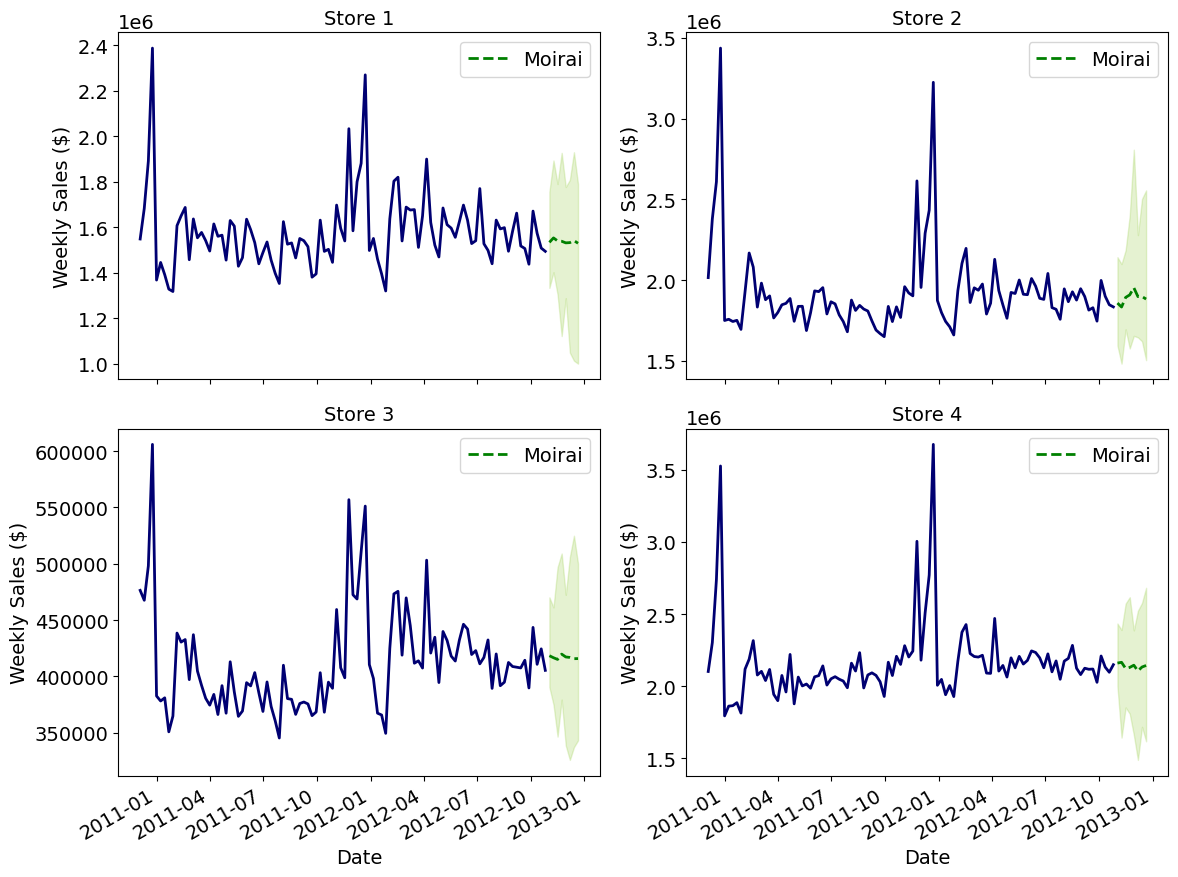

In [10]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12,9))

plot_df = df.reset_index(drop=False).copy()
plot_preds_df = preds_df.copy()

for i, ax in enumerate(axes.flatten()):
    df = plot_df[plot_df['Store'] == i+1].iloc[-100:]
    preds_df = plot_preds_df[plot_preds_df['Store'] == i+1]

    ax.plot(df['Date'], df['Weekly_Sales'])
    ax.plot(preds_df['Date'], preds_df['Moirai'], 'g--', label='Moirai')
    ax.fill_between(preds_df['Date'], preds_df['Moirai-lo-95'], preds_df['Moirai-hi-95'], alpha=0.2, color='#80c21d')
    ax.legend()
    ax.set_title(f'Store {i+1}')
    ax.set_xlabel('Date')
    ax.set_ylabel('Weekly Sales ($)')

fig.autofmt_xdate()
plt.tight_layout()
#plt.savefig("figures/CH06_F06_peixeiro2.png", dpi=300)
#plt.savefig('figures/CH06_F06_peixeiro2.pdf', format='pdf', bbox_inches='tight')